In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. LOAD DATA
# ============================================================
df = pd.read_csv(
    r"E:\eeg-analysis\eeg-analysis\cognitive_state_discrimination_dataset - cognitive_state_discrimination_dataset.csv"
)

print("="*60)
print("DATA INFO")
print("="*60)
print("Shape:", df.shape)
print("Columns:", len(df.columns))
print("\nFirst 5 rows:")
print(df.head())

DATA INFO
Shape: (40, 71)
Columns: 71

First 5 rows:
   Participant_ID                        Task  Channel_1_PSD  Channel_2_PSD  \
0               1               Resting State       0.497405       0.952911   
1               1               Memory Recall       0.465067       0.275623   
2               1      Arithmetic Calculation       0.533103       0.592343   
3               1  Visual Pattern Recognition       0.535369       0.038921   
4               2               Resting State       0.388730       0.541622   

   Channel_3_PSD  Channel_4_PSD  Channel_5_PSD  Channel_6_PSD  Channel_7_PSD  \
0       0.376679       0.867884       0.241254       0.353079       0.517339   
1       0.785774       0.128620       0.723935       0.049756       0.230252   
2       0.551308       0.469252       0.286355       0.580777       0.471439   
3       0.210236       0.060953       0.178834       0.227446       0.056417   
4       0.458615       0.606508       0.417763       0.524841       0.20

In [75]:
# ============================================================
# 2. PILIH 16 CHANNEL
# ============================================================
selected_channels = [
    1, 2, 5, 6, 10, 11, 23, 24,
    27, 28, 8, 9, 16, 17, 21, 22
]

feature_cols = [f"Channel_{ch}_PSD" for ch in selected_channels]

print("="*60)
print("SELECTED CHANNELS")
print("="*60)
print(f"Selected {len(selected_channels)} channels:")
for i, ch in enumerate(selected_channels, 1):
    print(f"{i:2d}. Channel_{ch}_PSD")

# ============================================================
# 3. PREPARE X & y
# ============================================================
X = df[feature_cols]
y = df["Target_Label"]

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("\nTarget distribution:")
print(y.value_counts().sort_index())

SELECTED CHANNELS
Selected 16 channels:
 1. Channel_1_PSD
 2. Channel_2_PSD
 3. Channel_5_PSD
 4. Channel_6_PSD
 5. Channel_10_PSD
 6. Channel_11_PSD
 7. Channel_23_PSD
 8. Channel_24_PSD
 9. Channel_27_PSD
10. Channel_28_PSD
11. Channel_8_PSD
12. Channel_9_PSD
13. Channel_16_PSD
14. Channel_17_PSD
15. Channel_21_PSD
16. Channel_22_PSD

Features shape: (40, 16)
Target shape: (40,)

Target distribution:
Target_Label
0    10
1    10
2    10
3    10
Name: count, dtype: int64


In [ ]:
# ============================================================
# 4. SPLIT DATA 70:30
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3   ``````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````,
    random_state=42,
    stratify=y
)

print("="*60)
print("DATA SPLIT")
print("="*60)
print(f"Training: {len(X_train)} samples (70%)")
print(f"Test: {len(X_test)} samples (30%)")

print("\nTraining set distribution:")
train_distribution = y_train.value_counts().sort_index()
for label, count in train_distribution.items()

DATA SPLIT
Training: 28 samples (70%)
Test: 12 samples (30%)

Training set distribution:
  Label 0: 7 samples (25.0%)
  Label 1: 7 samples (25.0%)
  Label 2: 7 samples (25.0%)
  Label 3: 7 samples (25.0%)

Testing set distribution:
  Label 0: 3 samples (25.0%)
  Label 1: 3 samples (25.0%)
  Label 2: 3 samples (25.0%)
  Label 3: 3 samples (25.0%)


In [77]:
# ============================================================
# 5. TRAIN RANDOM FOREST
# ============================================================
print("="*60)
print("TRAINING RANDOM FOREST")
print("="*60)

# Random Forest model dengan parameter yang dioptimasi
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees in the forest  
    random_state=42,       # For reproducibility
    max_depth=None,        # Maximum depth of the tree
    min_samples_split=2,   # Minimum number of samples required to split a node
    min_samples_leaf=1,    # Minimum number of samples required at each leaf node
    max_features='sqrt',   # Number of features to consider when looking for the best split
    n_jobs=-1              # Use all CPU cores
)

print("Training model...")
rf_model.fit(X_train, y_train)

# Prediksi
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Hitung akurasi
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n✓ Training Accuracy: {train_acc*100:.2f}%")
print(f"✓ Test Accuracy: {test_acc*100:.2f}%")
print(f"✓ Train-Test Gap: {(train_acc - test_acc)*100:.2f}%")

print(f"\nModel Info:")
print(f"  Number of trees: {rf_model.n_estimators}")
print(f"  Number of features: {rf_model.n_features_in_}")
print(f"  Feature names: {rf_model.feature_names_in_[:5]}...")

TRAINING RANDOM FOREST
Training model...

✓ Training Accuracy: 100.00%
✓ Test Accuracy: 25.00%
✓ Train-Test Gap: 75.00%

Model Info:
  Number of trees: 100
  Number of features: 16
  Feature names: ['Channel_1_PSD' 'Channel_2_PSD' 'Channel_5_PSD' 'Channel_6_PSD'
 'Channel_10_PSD']...


In [78]:
# ============================================================
# 6. DETAILED EVALUATION
# ============================================================
print("="*60)
print("EVALUATION RESULTS")
print("="*60)

# Calculate detailed metrics
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted')
recall = recall_score(y_test, y_test_pred, average='weighted')
f1 = f1_score(y_test, y_test_pred, average='weighted')

print("=== MODEL PERFORMANCE ===")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
target_names = ['Resting State', 'Memory Recall', 'Arithmetic Calculation', 'Visual Pattern Recognition']
class_report = classification_report(y_test, y_test_pred, target_names=target_names)
print(class_report)

print("\n=== CONFUSION MATRIX ===")
cm = confusion_matrix(y_test, y_test_pred)
print("Raw counts:")
print(cm)

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print("\nNormalized (by row):")
print(cm_normalized.round(3))

EVALUATION RESULTS
=== MODEL PERFORMANCE ===
Accuracy:  0.2500 (25.00%)
Precision: 0.3500
Recall:    0.2500
F1-Score:  0.2500

=== CLASSIFICATION REPORT ===
                            precision    recall  f1-score   support

             Resting State       1.00      0.33      0.50         3
             Memory Recall       0.40      0.67      0.50         3
    Arithmetic Calculation       0.00      0.00      0.00         3
Visual Pattern Recognition       0.00      0.00      0.00         3

                  accuracy                           0.25        12
                 macro avg       0.35      0.25      0.25        12
              weighted avg       0.35      0.25      0.25        12


=== CONFUSION MATRIX ===
Raw counts:
[[1 1 0 1]
 [0 2 0 1]
 [0 1 0 2]
 [0 1 2 0]]

Normalized (by row):
[[0.333 0.333 0.    0.333]
 [0.    0.667 0.    0.333]
 [0.    0.333 0.    0.667]
 [0.    0.333 0.667 0.   ]]


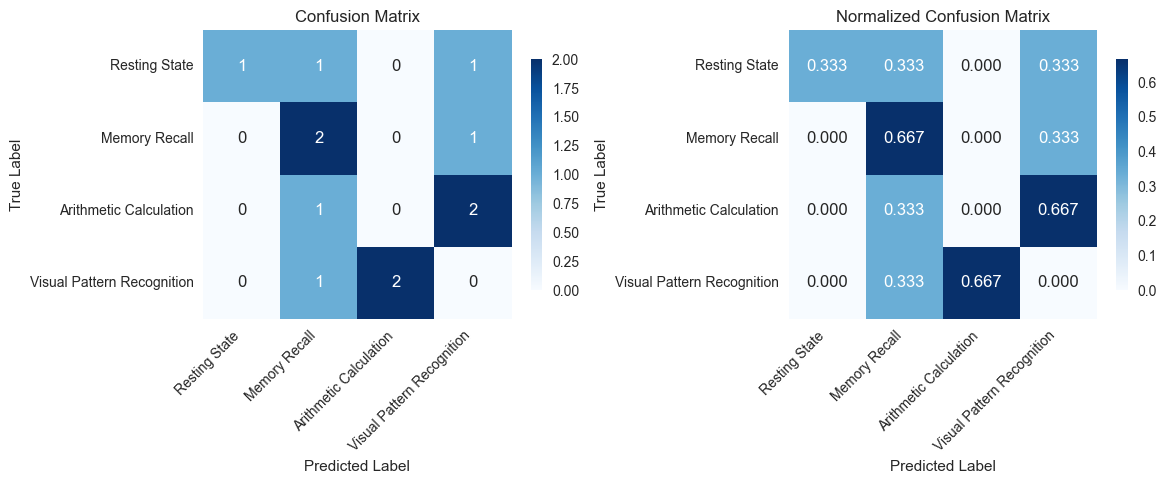

In [79]:
# ============================================================
# 7. CONFUSION MATRIX VISUALIZATION
# ============================================================
labels = ['Resting State', 'Memory Recall', 'Arithmetic Calculation', 'Visual Pattern Recognition']

plt.figure(figsize=(12, 5))

# Plot confusion matrix
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=labels, yticklabels=labels, cbar_kws={'shrink': 0.8})
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Plot normalized confusion matrix
plt.subplot(1, 2, 2)
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues', 
           xticklabels=labels, yticklabels=labels, cbar_kws={'shrink': 0.8})
plt.title('Normalized Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

FEATURE IMPORTANCE
=== RANKING ===
 1. Channel_22_PSD  - 0.1019
 2. Channel_10_PSD  - 0.0922
 3. Channel_21_PSD  - 0.0749
 4. Channel_23_PSD  - 0.0693
 5. Channel_27_PSD  - 0.0675
 6. Channel_5_PSD   - 0.0651
 7. Channel_28_PSD  - 0.0646
 8. Channel_24_PSD  - 0.0614
 9. Channel_6_PSD   - 0.0612
10. Channel_11_PSD  - 0.0576
11. Channel_2_PSD   - 0.0562
12. Channel_8_PSD   - 0.0546
13. Channel_16_PSD  - 0.0484
14. Channel_9_PSD   - 0.0421
15. Channel_1_PSD   - 0.0419
16. Channel_17_PSD  - 0.0409


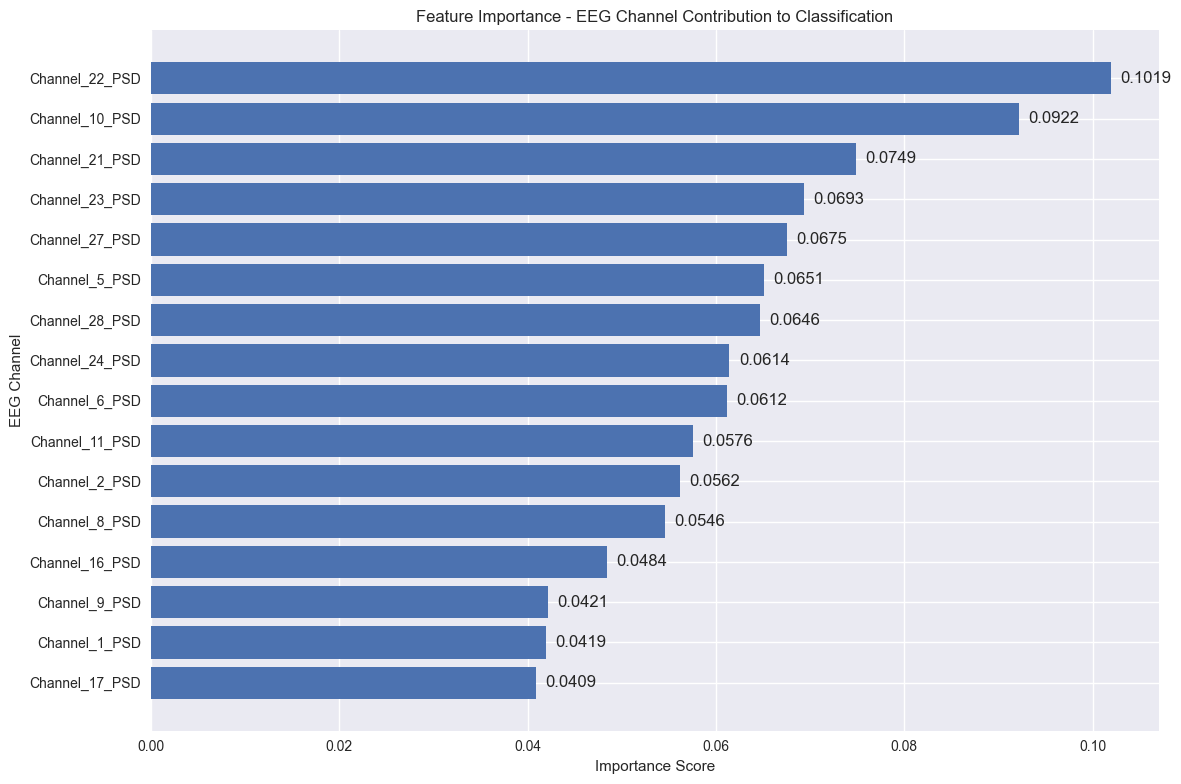


=== TOP 5 MOST IMPORTANT CHANNELS ===
1. Channel_22_PSD (Importance: 0.1019)
2. Channel_10_PSD (Importance: 0.0922)
3. Channel_21_PSD (Importance: 0.0749)
4. Channel_23_PSD (Importance: 0.0693)
5. Channel_27_PSD (Importance: 0.0675)


In [80]:
# ============================================================
# 8. FEATURE IMPORTANCE
# ============================================================
print("="*60)
print("FEATURE IMPORTANCE")
print("="*60)

feature_importance_data = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("=== RANKING ===")
for i, (index, row) in enumerate(feature_importance_data.iterrows(), 1):
    print(f"{i:2d}. {row['Feature']:15s} - {row['Importance']:.4f}")

# Visualize feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_data['Feature'], feature_importance_data['Importance'])
plt.title('Feature Importance - EEG Channel Contribution to Classification')
plt.xlabel('Importance Score')
plt.ylabel('EEG Channel')
plt.gca().invert_yaxis()  # Highest importance at the top

# Add value labels on bars
for i, v in enumerate(feature_importance_data['Importance']):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center')
    
plt.tight_layout()
plt.show()

print(f"\n=== TOP 5 MOST IMPORTANT CHANNELS ===")
top_5 = feature_importance_data.head(5)
for i, (index, row) in enumerate(top_5.iterrows(), 1):
    print(f"{i}. {row['Feature']} (Importance: {row['Importance']:.4f})")

In [81]:
# ============================================================
# 9. SAVE MODEL
# ============================================================
bundle = {
    "model": rf_model,
    "features": feature_cols,
    "feature_names": feature_cols,
    "target_labels": {
        0: 'Resting State',
        1: 'Memory Recall',
        2: 'Arithmetic Calculation',
        3: 'Visual Pattern Recognition'
    },
    "performance": {
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }
}

model_filename = r"E:\eeg-analysis\modules\cognitive_random_forest_model.pkl"
joblib.dump(bundle, model_filename)

print("="*60)
print("MODEL SAVED")
print("="*60)
print("✅ File: cognitive_random_forest_model.pkl")
print(f"✅ Model file size: {round(os.path.getsize(model_filename) / 1024, 2)} KB")
print(f"\nFinal Summary:")
print(f"  Model: Random Forest")
print(f"  Features: {len(feature_cols)} EEG channels")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"  Train-Test Gap: {(train_acc - test_acc)*100:.2f}%")
print("="*60)

MODEL SAVED
✅ File: cognitive_random_forest_model.pkl
✅ Model file size: 200.73 KB

Final Summary:
  Model: Random Forest
  Features: 16 EEG channels
  Test Accuracy: 25.00%
  Train-Test Gap: 75.00%


In [82]:
# ============================================================
# 10. TEST MODEL LOADING & USAGE
# ============================================================
import os

print("="*60)
print("TESTING MODEL LOADING")
print("="*60)

# Load model bundle
bundle_test = joblib.load(model_filename)
model_test = bundle_test["model"]
features_test = bundle_test["features"]
target_labels = bundle_test["target_labels"]

print("✅ Model loaded successfully!")
print(f"✅ Features required: {len(features_test)} channels")
print(f"✅ Target labels: {target_labels}")

# Contoh prediksi dengan data dummy
print("\n=== EXAMPLE PREDICTION ===")
sample_data = np.random.rand(1, len(features_test))  # 1 sample dengan 16 features
sample_df = pd.DataFrame(sample_data, columns=features_test)

# Prediksi
prediction = model_test.predict(sample_df)
prediction_proba = model_test.predict_proba(sample_df)

print(f"Input shape: {sample_df.shape}")
print(f"Predicted class: {prediction[0]} ({target_labels[prediction[0]]})")
print(f"Prediction probabilities: {prediction_proba[0].round(3)}")

print(f"\n=== USAGE INSTRUCTIONS ===")
print(f"1. Load model: bundle = joblib.load('{model_filename}')")
print(f"2. Get model: model = bundle['model']")
print(f"3. Get features: features = bundle['features']")
print(f"4. Prepare data with columns: {features_test}")
print(f"5. Predict: prediction = model.predict(your_data)")
print("="*60)

TESTING MODEL LOADING
✅ Model loaded successfully!
✅ Features required: 16 channels
✅ Target labels: {0: 'Resting State', 1: 'Memory Recall', 2: 'Arithmetic Calculation', 3: 'Visual Pattern Recognition'}

=== EXAMPLE PREDICTION ===
Input shape: (1, 16)
Predicted class: 3 (Visual Pattern Recognition)
Prediction probabilities: [0.24 0.23 0.26 0.27]

=== USAGE INSTRUCTIONS ===
1. Load model: bundle = joblib.load('E:\eeg-analysis\modules\cognitive_random_forest_model.pkl')
2. Get model: model = bundle['model']
3. Get features: features = bundle['features']
4. Prepare data with columns: ['Channel_1_PSD', 'Channel_2_PSD', 'Channel_5_PSD', 'Channel_6_PSD', 'Channel_10_PSD', 'Channel_11_PSD', 'Channel_23_PSD', 'Channel_24_PSD', 'Channel_27_PSD', 'Channel_28_PSD', 'Channel_8_PSD', 'Channel_9_PSD', 'Channel_16_PSD', 'Channel_17_PSD', 'Channel_21_PSD', 'Channel_22_PSD']
5. Predict: prediction = model.predict(your_data)


In [83]:
# ============================================================
# 11. PRODUCTION USAGE EXAMPLE
# ============================================================

# Contoh penggunaan model untuk prediksi data baru
# Uncomment dan edit path sesuai kebutuhan

"""
# Load model
bundle = joblib.load(r"E:\eeg-analysis\modules\cognitive_random_forest_model.pkl")
model = bundle["model"]
features = bundle["features"]
target_labels = bundle["target_labels"]

# Load data baru (ganti path sesuai file Anda)
new_data = pd.read_csv(r"E:\eeg-analysis\relax3.csv")

# Pastikan kolom sesuai model
new_data_features = new_data[features]

# Prediksi
predictions = model.predict(new_data_features)
prediction_proba = model.predict_proba(new_data_features)

# Tampilkan hasil
print("="*50)
print("HASIL PREDIKSI")
print("="*50)
print(f"Total data: {len(predictions)}")

# Hitung distribusi prediksi
for label in sorted(model.classes_):
    count = (predictions == label).sum()
    percentage = (count / len(predictions)) * 100
    print(f"Label {label} ({target_labels[label]}): {count} data ({percentage:.2f}%)")

# Simpan hasil (optional)
result_df = new_data_features.copy()
result_df['Predicted_Label'] = predictions
result_df['Predicted_Label_Name'] = [target_labels[pred] for pred in predictions]
# result_df.to_csv('prediction_results.csv', index=False)
"""

print("="*60)
print("MODEL TRAINING COMPLETED!")
print("="*60)
print("✅ Model tersimpan dan siap digunakan")
print("✅ Uncomment kode di atas untuk penggunaan")
print("="*60)

MODEL TRAINING COMPLETED!
✅ Model tersimpan dan siap digunakan
✅ Uncomment kode di atas untuk penggunaan
